In [1]:
%reload_ext autoreload
%autoreload 2
import socket
import os
import sys
hostname = socket.gethostname()
print('hostname: ', hostname)
print("current path: ", os.getcwd())
sys.path.append("/home/zzhang18/proj/Traj_Gen/")
# sys.path.append("/home/zzhang18/proj/minecraft/models")
print("search path: ", sys.path)

hostname:  gpu-4-13
current path:  /home/zzhang18/proj/Traj_Gen
search path:  ['/home/zzhang18/programs/anaconda3/envs/minecraft/lib/python310.zip', '/home/zzhang18/programs/anaconda3/envs/minecraft/lib/python3.10', '/home/zzhang18/programs/anaconda3/envs/minecraft/lib/python3.10/lib-dynload', '', '/home/zzhang18/programs/anaconda3/envs/minecraft/lib/python3.10/site-packages', '/home/zzhang18/proj/Traj_Gen/']


In [2]:
import numpy as np
import torch
from utils.utils import viz_trajs
import matplotlib.pyplot as plt

[[[104.10386638  30.69736258]
  [104.10384452  30.69736257]
  [104.10383638  30.69736257]
  ...
  [104.11232586  30.65870514]
  [104.11231588  30.65807305]
  [104.11230132  30.65750494]]

 [[104.04447339  30.7169397 ]
  [104.0447769   30.71654908]
  [104.04496074  30.71629865]
  ...
  [104.04111465  30.69576223]
  [104.04082834  30.69559964]
  [104.04054534  30.69541872]]

 [[104.09211828  30.68528701]
  [104.09211828  30.68528701]
  [104.09211828  30.68528701]
  ...
  [104.07211713  30.67617333]
  [104.07211713  30.67617333]
  [104.07211713  30.67617333]]

 ...

 [[104.07952802  30.67344793]
  [104.07952802  30.67344793]
  [104.07952802  30.67344793]
  ...
  [104.07888936  30.65932464]
  [104.07888936  30.65932464]
  [104.07888936  30.65932464]]

 [[104.04098274  30.72514354]
  [104.04179282  30.72578731]
  [104.04267624  30.72647442]
  ...
  [104.07894929  30.65942455]
  [104.07894929  30.65942455]
  [104.07894929  30.65942455]]

 [[104.0672338   30.69677958]
  [104.0672338   30.6967

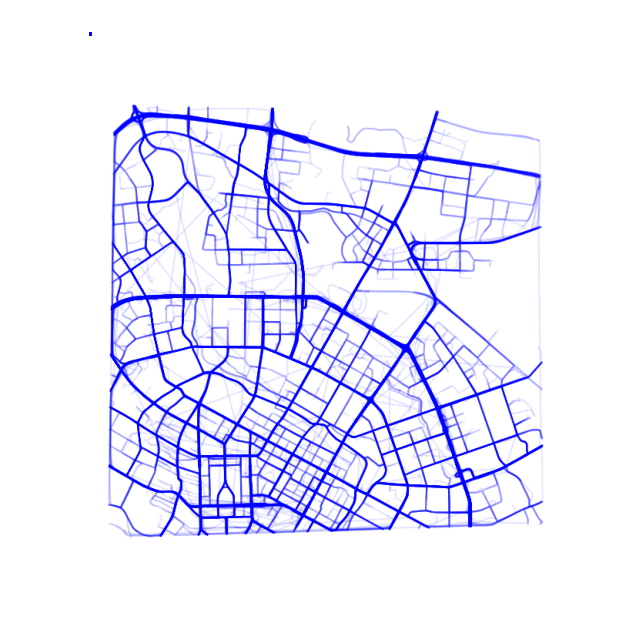

In [10]:
%reload_ext autoreload
%autoreload 2
label_test = np.load('datasets/chengdu/label_test.npy')
lengths = label_test[:,3].astype(np.int32)
data_test = np.load('./datasets/chengdu/data_test.npy')
data_test[:,:,0] = (data_test[:,:,0] - 104)*1000
data_test[:,:,1] = (data_test[:,:,1] - 30)*100
data_test[:,:,0] = (data_test[:,:,0] / 1000) + 104
data_test[:,:,1] = (data_test[:,:,1] / 100) + 30
print(data_test)
# print(data_test.dtype)
# print(data_test)
# data_test = data_test.astype(np.float32)
# data_test.dtype
# print(data_test)
# data_test = data_test.astype(np.float16)
# data_test.dtype
# data_test
image = viz_trajs(data_test, lengths, [104.03968953679004, 104.12705400673643], [30.655400079856072, 30.730172829483855])
plt.imshow(image)
plt.axis('off')  # Hide axis
plt.show()

In [9]:
%reload_ext autoreload
%autoreload 2
from datasets.traj_dataloader import TrajectoryData
city = 'chengdu'
dataset = TrajectoryData(
    f'/home/zzhang18/proj/Traj_Gen/datasets/{city}/data_train.npy',
    f'/home/zzhang18/proj/Traj_Gen/datasets/{city}/label_train.npy',
    f'/home/zzhang18/proj/Traj_Gen/datasets/{city}/traj_shift_mean.npy',
    f'/home/zzhang18/proj/Traj_Gen/datasets/{city}/traj_shift_std.npy'
)

In [10]:
dataset[0]

(array([[ 1.4862862, -1.0359861],
        [ 1.4862862, -1.0359861],
        [ 1.4862862, -1.0359861],
        [ 1.4853493, -1.0359865],
        [ 1.4836897, -1.0359876],
        [ 1.4816654, -1.0401542],
        [ 1.4823346, -1.0577067],
        [ 1.4830039, -1.0755136],
        [ 1.4834778, -1.0935067],
        [ 1.4834785, -1.1114057],
        [ 1.4833524, -1.1347967],
        [ 1.4830118, -1.1538677],
        [ 1.4830121, -1.1601434],
        [ 1.4830121, -1.1601434],
        [ 1.4830121, -1.1601434],
        [ 1.4830121, -1.1601434],
        [ 1.4830121, -1.1601434],
        [ 1.4830121, -1.1601434],
        [ 1.4830121, -1.1601434],
        [ 1.4830121, -1.1601434],
        [ 1.4830121, -1.1601434],
        [ 1.4830122, -1.1611552],
        [ 1.4825441, -1.1691037],
        [ 1.4825444, -1.1793587],
        [ 1.4825453, -1.1982486],
        [ 1.4825462, -1.2211572],
        [ 1.482547 , -1.2422413],
        [ 1.4827975, -1.2638416],
        [ 1.4830173, -1.285214 ],
        [ 1.48

In [2]:
data_test = np.load('datasets/chengdu/data_test.npy')
label_test = np.load('datasets/chengdu/label_test.npy')
print(data_test.shape, label_test.shape)
label_mean = np.load('datasets/chengdu/label_mean.npy')
label_std = np.load('datasets/chengdu/label_std.npy')
print(label_mean, label_std)
label_test[:,1:6] = (label_test[:,1:6] - label_mean) / label_std

lengths = (label_test[:,3] * label_std[2] + label_mean[2]).astype(np.int32)
print(lengths)
spatio_mean, spatio_std = np.load('datasets/chengdu/traj_mean.npy'), np.load('datasets/chengdu/traj_std.npy')
print(spatio_mean, spatio_std)

data_test = (data_test - spatio_mean) / spatio_std


(3000, 200, 2) (3000, 8)
[4973.431      824.9446     246.93033     21.175665     6.3370495] [2557.2024     402.54346    112.19926      9.7900095    2.7794955]
[339 242 150 ... 410 158 179]
[104.07657018  30.68205131] [0.02135474 0.01916107]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


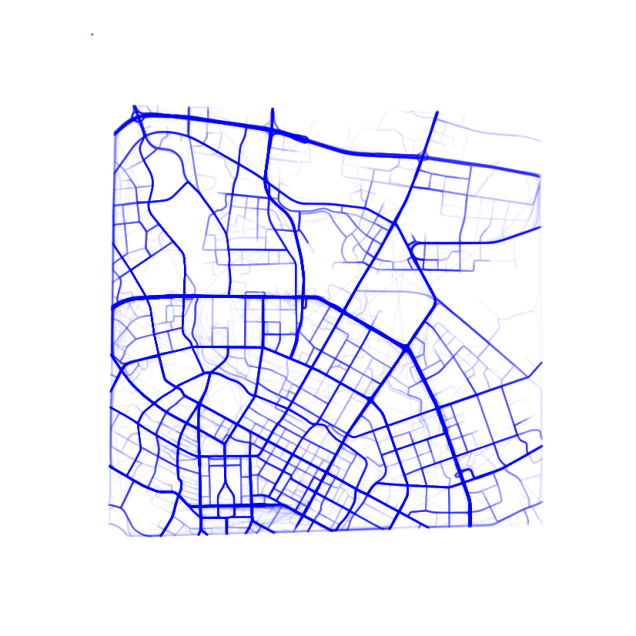

In [ ]:
%load_ext autoreload
%autoreload 2
data_train = np.load('datasets/chengdu/data_train.npy')[10000:20000]
label_train = np.load('datasets/chengdu/label_train.npy')[10000:20000]
label_train[:,1:6] = (label_train[:,1:6] - label_mean) / label_std

lengths = (label_train[:,3] * label_std[2] + label_mean[2]).astype(np.int32)
image = viz_trajs(data_train, lengths, spatio_mean, spatio_std, [104.03968953679004, 104.12705400673643], [30.655400079856072, 30.730172829483855])

plt.imshow(image)
plt.axis('off')  # Hide axis
plt.show()